In [ ]:
!uv pip install ccxt


In [ ]:
from model import Kronos, KronosTokenizer, KronosPredictor

# Load from Hugging Face Hub
tokenizer = KronosTokenizer.from_pretrained("NeoQuasar/Kronos-Tokenizer-base")
model = Kronos.from_pretrained("NeoQuasar/Kronos-base")


In [ ]:
# Initialize the predictor
predictor = KronosPredictor(model, tokenizer, max_context=512)


In [ ]:
from ccxt import okx
import pandas as pd

symbol = "BTC/USDT"
timeframe = "4h"
lookback = 400
pred_len = 120

okx_client = okx({"enableRateLimit": True})
market_data = okx_client.fetch_ohlcv(
    symbol,
    timeframe=timeframe,
    limit=lookback,
    params={"paginate": True},
)
df = pd.DataFrame(
    market_data,
    columns=["timestamp", "open", "high", "low", "close", "volume"],
)
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
df = df.sort_values("timestamp").reset_index(drop=True)

if len(df) < 2:
    raise ValueError("Need at least two OHLCV rows to infer the candle interval.")

lookback = min(lookback, len(df))
freq = pd.Timedelta(seconds=okx_client.parse_timeframe(timeframe))

# Prepare inputs for the predictor
x_df = df.iloc[-lookback:][["open", "high", "low", "close", "volume"]].reset_index(
    drop=True
)
x_timestamp = df.iloc[-lookback:]["timestamp"].reset_index(drop=True)
y_timestamp = pd.Series(
    pd.date_range(
        start=df["timestamp"].iloc[-1] + freq,
        periods=pred_len,
        freq=freq,
    )
)


In [ ]:
# Generate predictions
pred_df = predictor.predict(
    df=x_df,
    x_timestamp=x_timestamp,
    y_timestamp=y_timestamp,
    pred_len=pred_len,
    T=1.0,  # Temperature for sampling
    top_p=0.9,  # Nucleus sampling probability
    sample_count=1,  # Number of forecast paths to generate and average
)

print("Forecasted Data Head:")
# print(pred_df.head())
display(pred_df)


100%|██████████| 120/120 [00:09<00:00, 12.64it/s]

Forecasted Data Head:


,open,high,low,close,volume,amount
2026-05-13 20:00:00,79322.562500,79735.625000,79062.703125,79468.539062,399.664856,29998388.0
2026-05-14 00:00:00,79281.937500,80049.179688,78321.804688,78518.351562,916.730164,69832592.0
2026-05-14 04:00:00,78481.859375,79562.742188,78321.507812,79257.515625,1380.695801,105205008.0
2026-05-14 08:00:00,78987.125000,79207.632812,78188.804688,78476.828125,1041.842529,79193280.0
2026-05-14 12:00:00,78431.804688,78880.468750,78055.742188,78472.234375,851.495239,63668440.0
...,...,...,...,...,...,...
2026-06-02 00:00:00,73110.710938,73326.101562,72624.218750,72817.718750,411.923950,29739272.0
2026-06-02 04:00:00,73136.335938,73128.757812,72925.093750,72761.085938,538.526550,39982500.0
2026-06-02 08:00:00,72793.625000,73045.328125,72414.421875,72617.914062,415.449402,29961752.0
2026-06-02 12:00:00,72376.226562,72709.335938,72187.429688,72469.445312,268.263062,19446368.0


In [ ]:
import matplotlib.pyplot as plt


def plot_prediction(kline_df, pred_df, x_timestamp=None):
    kline_df = kline_df.copy()
    pred_df = pred_df.copy()

    if x_timestamp is not None:
        kline_df.index = pd.to_datetime(pd.Series(x_timestamp).to_numpy())
    elif "timestamp" in kline_df.columns:
        kline_df.index = pd.to_datetime(kline_df["timestamp"])
    elif "timestamps" in kline_df.columns:
        kline_df.index = pd.to_datetime(kline_df["timestamps"])

    pred_df.index = pd.to_datetime(pred_df.index)

    sr_close = kline_df["close"]
    sr_pred_close = pred_df["close"]
    sr_close.name = "Ground Truth"
    sr_pred_close.name = "Prediction"

    sr_volume = kline_df["volume"]
    sr_pred_volume = pred_df["volume"]
    sr_volume.name = "Ground Truth"
    sr_pred_volume.name = "Prediction"

    close_df = pd.concat([sr_close, sr_pred_close], axis=1)
    volume_df = pd.concat([sr_volume, sr_pred_volume], axis=1)
    close_truth = close_df["Ground Truth"].dropna()
    close_pred = close_df["Prediction"].dropna()
    volume_truth = volume_df["Ground Truth"].dropna()
    volume_pred = volume_df["Prediction"].dropna()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    ax1.plot(
        close_truth.index,
        close_truth.values,
        label="Ground Truth",
        color="blue",
        linewidth=1.5,
    )
    ax1.plot(
        close_pred.index,
        close_pred.values,
        label="Prediction",
        color="red",
        linewidth=1.5,
    )
    ax1.set_ylabel("Close Price", fontsize=14)
    ax1.legend(loc="lower left", fontsize=12)
    ax1.grid(True)

    ax2.plot(
        volume_truth.index,
        volume_truth.values,
        label="Ground Truth",
        color="blue",
        linewidth=1.5,
    )
    ax2.plot(
        volume_pred.index,
        volume_pred.values,
        label="Prediction",
        color="red",
        linewidth=1.5,
    )
    ax2.set_ylabel("Volume", fontsize=14)
    ax2.legend(loc="upper left", fontsize=12)
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


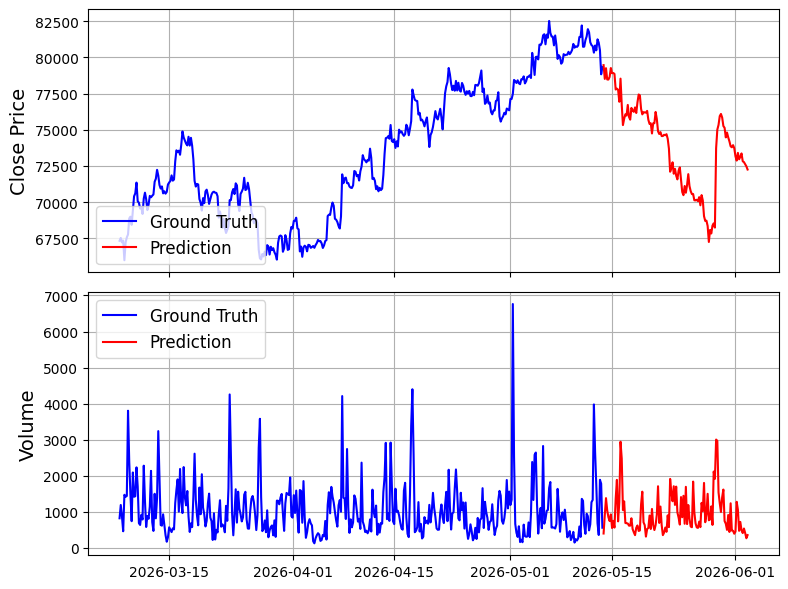

,open,high,low,close,volume,amount
2026-05-13 20:00:00,79322.562500,79735.625000,79062.703125,79468.539062,399.664856,29998388.0
2026-05-14 00:00:00,79281.937500,80049.179688,78321.804688,78518.351562,916.730164,69832592.0
2026-05-14 04:00:00,78481.859375,79562.742188,78321.507812,79257.515625,1380.695801,105205008.0
2026-05-14 08:00:00,78987.125000,79207.632812,78188.804688,78476.828125,1041.842529,79193280.0
2026-05-14 12:00:00,78431.804688,78880.468750,78055.742188,78472.234375,851.495239,63668440.0
...,...,...,...,...,...,...
2026-06-02 00:00:00,73110.710938,73326.101562,72624.218750,72817.718750,411.923950,29739272.0
2026-06-02 04:00:00,73136.335938,73128.757812,72925.093750,72761.085938,538.526550,39982500.0
2026-06-02 08:00:00,72793.625000,73045.328125,72414.421875,72617.914062,415.449402,29961752.0
2026-06-02 12:00:00,72376.226562,72709.335938,72187.429688,72469.445312,268.263062,19446368.0


In [ ]:
plot_prediction(x_df, pred_df, x_timestamp=x_timestamp)
pred_df
